In [39]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

import tools.tools as T
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT: d:\test\PCA\test_DR\0518


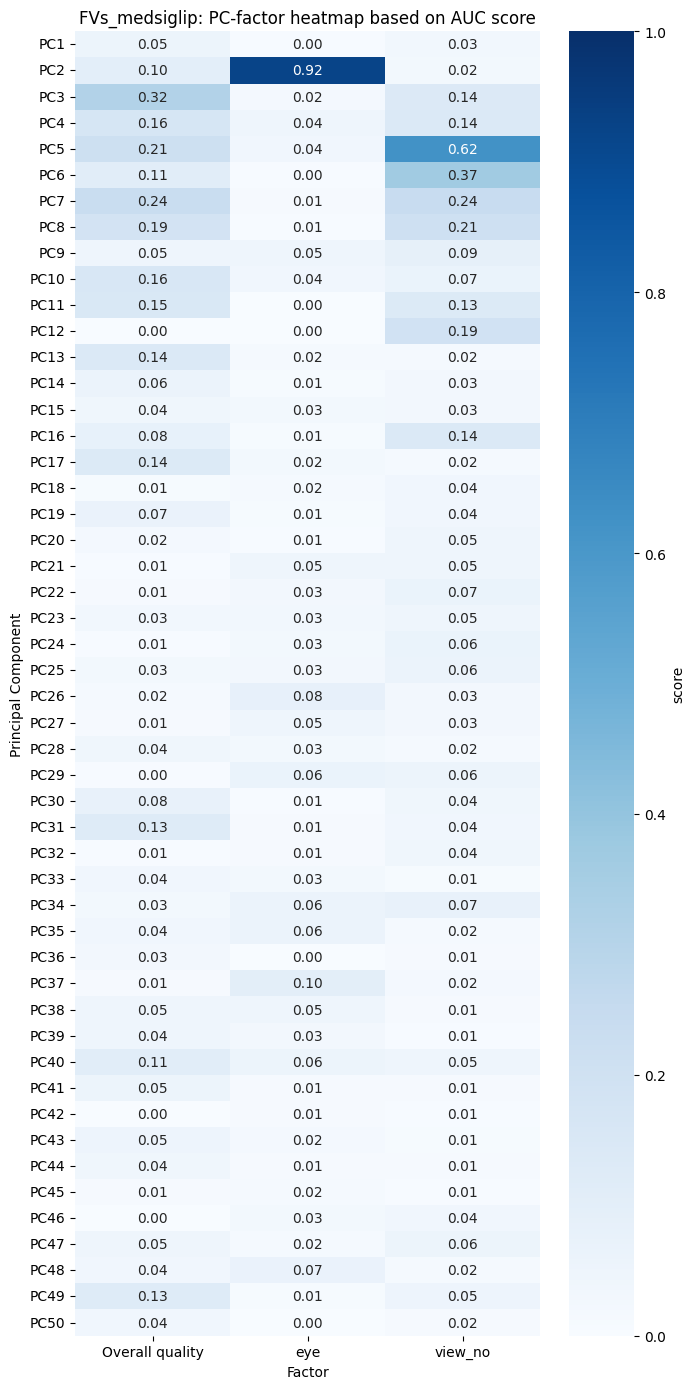

,PC,factor,method,raw_value,score,signed_score,auc_raw,auc_signed_score,spearman_rho,p_value,negative_label,positive_label,n,n_negative,n_positive,mean_PC_negative,mean_PC_positive
0,PC2,eye,auc,0.961727,0.923453,0.923453,0.961727,0.923453,NaN,NaN,l,r,1189,594,595,-9.910005,9.893349
1,PC5,view_no,auc,0.188612,0.622777,-0.622777,0.188612,-0.622777,NaN,NaN,1,2,1189,594,595,3.880117,-3.873596
2,PC6,view_no,auc,0.316866,0.366268,-0.366268,0.316866,-0.366268,NaN,NaN,1,2,1189,594,595,2.047900,-2.044458
3,PC3,Overall quality,auc,0.657741,0.315483,0.315483,0.657741,0.315483,NaN,NaN,0,1,1189,620,569,-2.615057,2.849447
4,PC7,view_no,auc,0.380729,0.238542,-0.238542,0.380729,-0.238542,NaN,NaN,1,2,1189,594,595,1.343387,-1.341129
5,PC7,Overall quality,auc,0.618207,0.236414,0.236414,0.618207,0.236414,NaN,NaN,0,1,1189,620,569,-1.308892,1.426209
6,PC5,Overall quality,auc,0.394393,0.211214,-0.211214,0.394393,-0.211214,NaN,NaN,0,1,1189,620,569,1.309999,-1.427415
7,PC8,view_no,auc,0.396469,0.207062,-0.207062,0.396469,-0.207062,NaN,NaN,1,2,1189,594,595,1.018387,-1.016675
8,PC12,view_no,auc,0.597021,0.194041,0.194041,0.597021,0.194041,NaN,NaN,1,2,1189,594,595,-0.620605,0.619562
9,PC8,Overall quality,auc,0.593665,0.187329,0.187329,0.593665,0.187329,NaN,NaN,0,1,1189,620,569,-0.959359,1.045347


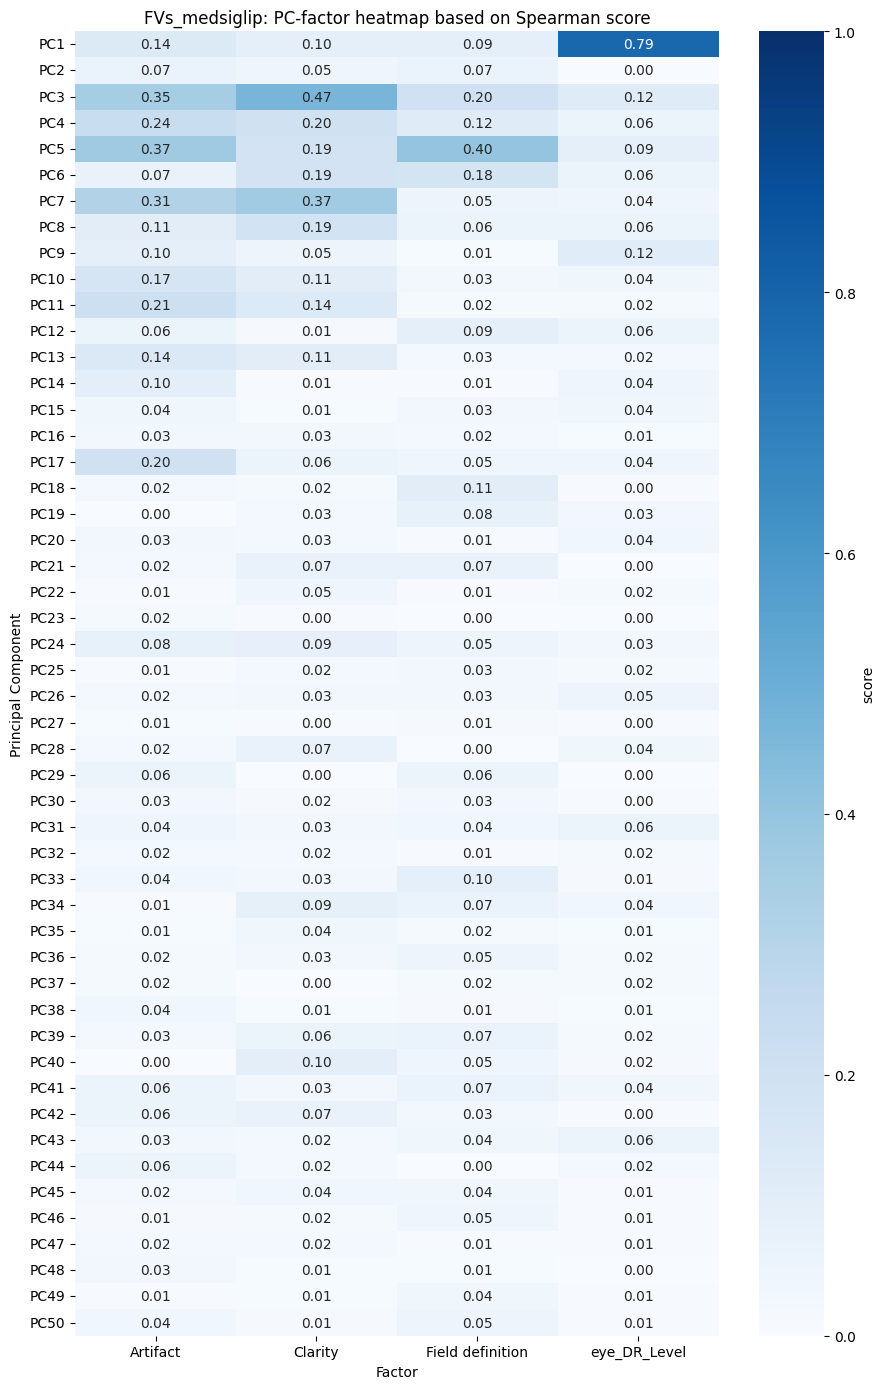

,PC,factor,method,raw_value,score,signed_score,auc_raw,auc_signed_score,spearman_rho,p_value,negative_label,positive_label,n,n_negative,n_positive,mean_PC_negative,mean_PC_positive
0,PC1,eye_DR_Level,spearman,-0.787509,0.787509,-0.787509,NaN,NaN,-0.787509,8.999141e-252,NaN,NaN,1189,NaN,NaN,NaN,NaN
1,PC3,Clarity,spearman,0.466898,0.466898,0.466898,NaN,NaN,0.466898,2.062211e-65,NaN,NaN,1189,NaN,NaN,NaN,NaN
2,PC5,Field definition,spearman,-0.401609,0.401609,-0.401609,NaN,NaN,-0.401609,2.645826e-47,NaN,NaN,1189,NaN,NaN,NaN,NaN
3,PC5,Artifact,spearman,0.372877,0.372877,0.372877,NaN,NaN,0.372877,1.599977e-40,NaN,NaN,1189,NaN,NaN,NaN,NaN
4,PC7,Clarity,spearman,0.366321,0.366321,0.366321,NaN,NaN,0.366321,4.555473e-39,NaN,NaN,1189,NaN,NaN,NaN,NaN
5,PC3,Artifact,spearman,-0.352623,0.352623,-0.352623,NaN,NaN,-0.352623,3.890039e-36,NaN,NaN,1189,NaN,NaN,NaN,NaN
6,PC7,Artifact,spearman,-0.313659,0.313659,-0.313659,NaN,NaN,-0.313659,1.481738e-28,NaN,NaN,1189,NaN,NaN,NaN,NaN
7,PC4,Artifact,spearman,-0.236889,0.236889,-0.236889,NaN,NaN,-0.236889,1.253729e-16,NaN,NaN,1189,NaN,NaN,NaN,NaN
8,PC11,Artifact,spearman,0.211819,0.211819,0.211819,NaN,NaN,0.211819,1.581425e-13,NaN,NaN,1189,NaN,NaN,NaN,NaN
9,PC3,Field definition,spearman,0.203226,0.203226,0.203226,NaN,NaN,0.203226,1.503323e-12,NaN,NaN,1189,NaN,NaN,NaN,NaN


In [43]:
# MedSigLIP 的 PC-factor 热力图：AUC 与 Spearman 分开绘制
# 说明：
#   AUC 热力图：score = 2 * abs(AUC_raw - 0.5)，表示二值因子与 PC 的关系强度
#   Spearman 热力图：score = abs(spearman_rho)，表示有序因子与 PC 的单调相关强度
#   如果想看方向性：
#       AUC 可把 value_col 改成 "auc_signed_score"
#       Spearman 可把 value_col 改成 "spearman_rho"

model_name = "FVs_medsiglip"
n_pc = 50

# 重新读取 MedSigLIP 特征并做 PCA
medsiglip_result = T.pca_for_model(
    model_name=model_name,
    n_components=n_pc,
    standardize=True,
)

pca_df = medsiglip_result["pca_df"]
meta_df = medsiglip_result["meta_df"].copy()

# 如果 metadata 中没有 view_no，则从 image_path 末尾的 l1/l2/r1/r2 推断
if "view_no" not in meta_df.columns:
    meta_df = T.add_view_no_column(
        meta_df=meta_df,
        image_path_col="image_path",
        view_col="view_no",
        overwrite=False,
        strict=False,
    )

# 二值因子：用 AUC
auc_cols = [
    "Overall quality",
    "eye",
    "view_no",
]

# 有序因子：用 Spearman
spearman_cols = [
    # "patient_DR_Level",
    "eye_DR_Level",
    "Clarity",
    "Field definition",
    "Artifact",
]

# 只保留当前 metadata 中实际存在的列，避免列名缺失时报错
auc_cols = [c for c in auc_cols if c in meta_df.columns]
spearman_cols = [c for c in spearman_cols if c in meta_df.columns]

# AUC 的正类定义
positive_label_map = {
    "Overall quality": 1,
    "eye": "r",
    "view_no": 2,
}

# ========== 1. AUC 热力图 ==========
auc_score_df = T.compute_pc_auc_table(
    pca_df=pca_df,
    meta_df=meta_df,
    auc_cols=auc_cols,
    n_pc=n_pc,
    positive_label_map=positive_label_map,
)

auc_score_mat = T.make_pc_factor_matrix(
    auc_score_df,
    value_col="score",
)

T.plot_pc_factor_heatmap(
    auc_score_mat,
    title=f"{model_name}: PC-factor heatmap based on AUC score",
    figsize=(7, 14),
    annot=True,
    vmin=0,
    vmax=1,
    cmap="Blues",
)

display(
    auc_score_df
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

# ========== 2. Spearman 热力图 ==========
spearman_score_df = T.compute_pc_spearman_table(
    pca_df=pca_df,
    meta_df=meta_df,
    spearman_cols=spearman_cols,
    n_pc=n_pc,
)

spearman_score_mat = T.make_pc_factor_matrix(
    spearman_score_df,
    value_col="score",
)

T.plot_pc_factor_heatmap(
    spearman_score_mat,
    title=f"{model_name}: PC-factor heatmap based on Spearman score",
    figsize=(9, 14),
    annot=True,
    vmin=0,
    vmax=1,
    cmap="Blues",
)

display(
    spearman_score_df
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
    .head(10)
)

In [40]:
model_list = [
    "FVs_medsiglip",
    "FVs_FLAIR",
    "FVs_LLM2CLIP-openai",
    "FVs_ConceptCLIP",
    "FVs_MONET",
    "FVs_SigLIP"
]

all_fold_df = []
all_summary_df = []
all_selection_df = []
all_score_df = []

for model_name in model_list:
    print(f"\n\n==============================")
    print(f"Running model: {model_name}")
    print(f"==============================")

    X, meta_df = T.load_aligned_features(model_name)

    fold_df, summary_df, selection_df, score_df_cv = T.evaluate_pc_removal_effect_auto_fold(
        X=X,
        meta_df=meta_df,
        y_col="eye_DR_Level",
        model_name=model_name,

        n_components=50,
        n_splits=5,

        auc_cols=[
            "Overall quality",
            "eye",
            "view_no",
        ],

        spearman_cols=[
            "eye_DR_Level",
            "Clarity",
            "Field definition",
            "Artifact",
        ],

        disease_cols=[
            "eye_DR_Level",
        ],

        nuisance_cols=[
            "Overall quality",
            "eye",
            "view_no",
            "Clarity",
            "Field definition",
            "Artifact",
        ],

        positive_label_map={
            "Overall quality": 1,
            "eye": "r",
            "view_no": 2,
        },

        nuisance_threshold=0.30,
        disease_threshold=0.20,
        margin_threshold=0.10,
        max_remove=1,

        C=1.0,
        class_weight="balanced",
        max_iter=200000,
        random_state=42,

        verbose=True,
    )

    all_fold_df.append(fold_df)
    all_summary_df.append(summary_df)
    all_selection_df.append(selection_df)
    all_score_df.append(score_df_cv)

all_fold_df = pd.concat(all_fold_df, axis=0, ignore_index=True)
all_summary_df = pd.concat(all_summary_df, axis=0, ignore_index=True)
all_selection_df = pd.concat(all_selection_df, axis=0, ignore_index=True)
all_score_df = pd.concat(all_score_df, axis=0, ignore_index=True)

all_summary_df.sort_values("delta_qwk_mean", ascending=False)



Running model: FVs_medsiglip
===== FVs_medsiglip | Fold 1 =====
  selected PCs: ['PC2']
===== FVs_medsiglip | Fold 2 =====
  selected PCs: ['PC2']
===== FVs_medsiglip | Fold 3 =====
  selected PCs: ['PC2']
===== FVs_medsiglip | Fold 4 =====
  selected PCs: ['PC2']
===== FVs_medsiglip | Fold 5 =====
  selected PCs: ['PC2']


Running model: FVs_FLAIR
===== FVs_FLAIR | Fold 1 =====
  selected PCs: ['PC3']
===== FVs_FLAIR | Fold 2 =====
  selected PCs: []
===== FVs_FLAIR | Fold 3 =====
  selected PCs: ['PC2']
===== FVs_FLAIR | Fold 4 =====
  selected PCs: ['PC3']
===== FVs_FLAIR | Fold 5 =====
  selected PCs: ['PC3']


Running model: FVs_LLM2CLIP-openai
===== FVs_LLM2CLIP-openai | Fold 1 =====
  selected PCs: ['PC5']
===== FVs_LLM2CLIP-openai | Fold 2 =====
  selected PCs: ['PC5']
===== FVs_LLM2CLIP-openai | Fold 3 =====
  selected PCs: ['PC5']
===== FVs_LLM2CLIP-openai | Fold 4 =====
  selected PCs: ['PC5']
===== FVs_LLM2CLIP-openai | Fold 5 =====
  selected PCs: ['PC5']


Running model

,raw_qwk_mean,raw_qwk_std,clean_qwk_mean,clean_qwk_std,delta_qwk_mean,delta_qwk_std,raw_accuracy_mean,raw_accuracy_std,clean_accuracy_mean,clean_accuracy_std,delta_accuracy_mean,delta_accuracy_std,raw_macro_f1_mean,raw_macro_f1_std,clean_macro_f1_mean,clean_macro_f1_std,delta_macro_f1_mean,delta_macro_f1_std,n_removed_mean,n_removed_std,n_removed_min,n_removed_max,removed_pcs_by_fold,split_mode,model_name
4,0.653440,0.055576,0.656632,0.043429,0.003192,0.022002,0.590416,0.023787,0.592089,0.018430,0.001674,0.014130,0.498246,0.029821,0.497875,0.017628,-0.000371,0.016263,1.0,0.000000,1,1,fold1:PC1 | fold2:PC5 | fold3:PC1 | fold4:PC1 | fold5:PC1,StratifiedKFold,FVs_MONET
3,0.662604,0.055446,0.663830,0.053870,0.001225,0.036620,0.596263,0.032212,0.591231,0.036144,-0.005031,0.020030,0.513171,0.035528,0.507979,0.042033,-0.005192,0.015368,1.0,0.000000,1,1,fold1:PC2 | fold2:PC2 | fold3:PC3 | fold4:PC2 | fold5:PC2,StratifiedKFold,FVs_ConceptCLIP
2,0.728297,0.050028,0.726006,0.052594,-0.002291,0.005200,0.635000,0.027571,0.640049,0.016562,0.005049,0.013746,0.547159,0.031355,0.553223,0.023040,0.006065,0.014515,1.0,0.000000,1,1,fold1:PC5 | fold2:PC5 | fold3:PC5 | fold4:PC5 | fold5:PC5,StratifiedKFold,FVs_LLM2CLIP-openai
5,0.703915,0.071591,0.694197,0.060415,-0.009718,0.029798,0.599653,0.032900,0.590405,0.026128,-0.009247,0.016380,0.513579,0.062259,0.503170,0.054151,-0.010408,0.024773,1.0,0.000000,1,1,fold1:PC7 | fold2:PC7 | fold3:PC8 | fold4:PC8 | fold5:PC7,StratifiedKFold,FVs_SigLIP
0,0.787441,0.049628,0.775164,0.046338,-0.012277,0.019757,0.677861,0.017954,0.673648,0.025611,-0.004212,0.007875,0.613698,0.025950,0.610598,0.028877,-0.003100,0.006865,1.0,0.000000,1,1,fold1:PC2 | fold2:PC2 | fold3:PC2 | fold4:PC2 | fold5:PC2,StratifiedKFold,FVs_medsiglip
1,0.856753,0.027591,0.844356,0.022708,-0.012397,0.025016,0.744311,0.016884,0.732532,0.017297,-0.011779,0.011667,0.708936,0.027529,0.692442,0.034865,-0.016495,0.019817,0.8,0.447214,0,1,fold1:PC3 | fold2:None | fold3:PC2 | fold4:PC3 | fold5:PC3,StratifiedKFold,FVs_FLAIR


In [41]:
# 结果保存目录：项目根目录/0518/output/qwk/max3
output_dir = PROJECT_ROOT / "output" / "qwk" / "max1"
output_dir.mkdir(parents=True, exist_ok=True)

# 按 QWK 改变量排序
all_summary_df_sorted = all_summary_df.sort_values(
    "delta_qwk_mean",
    ascending=False,
).reset_index(drop=True)

# 保存 CSV：不会像 notebook 打印那样省略
all_summary_df_sorted.to_csv(
    output_dir / "summary_qwk_max3.csv",
    index=False,
    encoding="utf-8-sig",
)
all_fold_df.to_csv(
    output_dir / "fold_qwk_max3.csv",
    index=False,
    encoding="utf-8-sig",
)
all_selection_df.to_csv(
    output_dir / "selection_qwk_max3.csv",
    index=False,
    encoding="utf-8-sig",
)
all_score_df.to_csv(
    output_dir / "score_qwk_max3.csv",
    index=False,
    encoding="utf-8-sig",
)

# 另存 Excel，方便查看
excel_path = output_dir / "qwk_max3_all_results.xlsx"

try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        all_summary_df_sorted.to_excel(writer, sheet_name="summary", index=False)
        all_fold_df.to_excel(writer, sheet_name="fold", index=False)
        all_selection_df.to_excel(writer, sheet_name="selection", index=False)
        all_score_df.to_excel(writer, sheet_name="score", index=False)
except ImportError:
    print("警告：当前环境没有 openpyxl，因此只保存 CSV。")

print("保存完成:")
print(output_dir)

print("\n输出文件:")
for path in sorted(output_dir.glob("*")):
    print("-", path.name)

# notebook 显示时尽量不省略
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 240)

all_summary_df_sorted

警告：当前环境没有 openpyxl，因此只保存 CSV。
保存完成:
d:\test\PCA\test_DR\0518\output\qwk\max1

输出文件:
- fold_qwk_max3.csv
- score_qwk_max3.csv
- selection_qwk_max3.csv
- summary_qwk_max3.csv


,raw_qwk_mean,raw_qwk_std,clean_qwk_mean,clean_qwk_std,delta_qwk_mean,delta_qwk_std,raw_accuracy_mean,raw_accuracy_std,clean_accuracy_mean,clean_accuracy_std,delta_accuracy_mean,delta_accuracy_std,raw_macro_f1_mean,raw_macro_f1_std,clean_macro_f1_mean,clean_macro_f1_std,delta_macro_f1_mean,delta_macro_f1_std,n_removed_mean,n_removed_std,n_removed_min,n_removed_max,removed_pcs_by_fold,split_mode,model_name
0,0.653440,0.055576,0.656632,0.043429,0.003192,0.022002,0.590416,0.023787,0.592089,0.018430,0.001674,0.014130,0.498246,0.029821,0.497875,0.017628,-0.000371,0.016263,1.0,0.000000,1,1,fold1:PC1 | fold2:PC5 | fold3:PC1 | fold4:PC1 | fold5:PC1,StratifiedKFold,FVs_MONET
1,0.662604,0.055446,0.663830,0.053870,0.001225,0.036620,0.596263,0.032212,0.591231,0.036144,-0.005031,0.020030,0.513171,0.035528,0.507979,0.042033,-0.005192,0.015368,1.0,0.000000,1,1,fold1:PC2 | fold2:PC2 | fold3:PC3 | fold4:PC2 | fold5:PC2,StratifiedKFold,FVs_ConceptCLIP
2,0.728297,0.050028,0.726006,0.052594,-0.002291,0.005200,0.635000,0.027571,0.640049,0.016562,0.005049,0.013746,0.547159,0.031355,0.553223,0.023040,0.006065,0.014515,1.0,0.000000,1,1,fold1:PC5 | fold2:PC5 | fold3:PC5 | fold4:PC5 | fold5:PC5,StratifiedKFold,FVs_LLM2CLIP-openai
3,0.703915,0.071591,0.694197,0.060415,-0.009718,0.029798,0.599653,0.032900,0.590405,0.026128,-0.009247,0.016380,0.513579,0.062259,0.503170,0.054151,-0.010408,0.024773,1.0,0.000000,1,1,fold1:PC7 | fold2:PC7 | fold3:PC8 | fold4:PC8 | fold5:PC7,StratifiedKFold,FVs_SigLIP
4,0.787441,0.049628,0.775164,0.046338,-0.012277,0.019757,0.677861,0.017954,0.673648,0.025611,-0.004212,0.007875,0.613698,0.025950,0.610598,0.028877,-0.003100,0.006865,1.0,0.000000,1,1,fold1:PC2 | fold2:PC2 | fold3:PC2 | fold4:PC2 | fold5:PC2,StratifiedKFold,FVs_medsiglip
5,0.856753,0.027591,0.844356,0.022708,-0.012397,0.025016,0.744311,0.016884,0.732532,0.017297,-0.011779,0.011667,0.708936,0.027529,0.692442,0.034865,-0.016495,0.019817,0.8,0.447214,0,1,fold1:PC3 | fold2:None | fold3:PC2 | fold4:PC3 | fold5:PC3,StratifiedKFold,FVs_FLAIR


,model_name,raw_qwk_mean,clean_qwk_mean,delta_qwk_mean,n_removed_mean,removed_pcs_by_fold
0,FVs_medsiglip,0.787441,0.775164,-0.012277,1.0,fold1:PC2 | fold2:PC2 | fold3:PC2 | fold4:PC2 | fold5:PC2
1,FVs_FLAIR,0.856753,0.844356,-0.012397,0.8,fold1:PC3 | fold2:None | fold3:PC2 | fold4:PC3 | fold5:PC3
2,FVs_LLM2CLIP-openai,0.728297,0.726006,-0.002291,1.0,fold1:PC5 | fold2:PC5 | fold3:PC5 | fold4:PC5 | fold5:PC5
3,FVs_ConceptCLIP,0.662604,0.663830,0.001225,1.0,fold1:PC2 | fold2:PC2 | fold3:PC3 | fold4:PC2 | fold5:PC2
4,FVs_MONET,0.653440,0.656632,0.003192,1.0,fold1:PC1 | fold2:PC5 | fold3:PC1 | fold4:PC1 | fold5:PC1
5,FVs_SigLIP,0.703915,0.694197,-0.009718,1.0,fold1:PC7 | fold2:PC7 | fold3:PC8 | fold4:PC8 | fold5:PC7


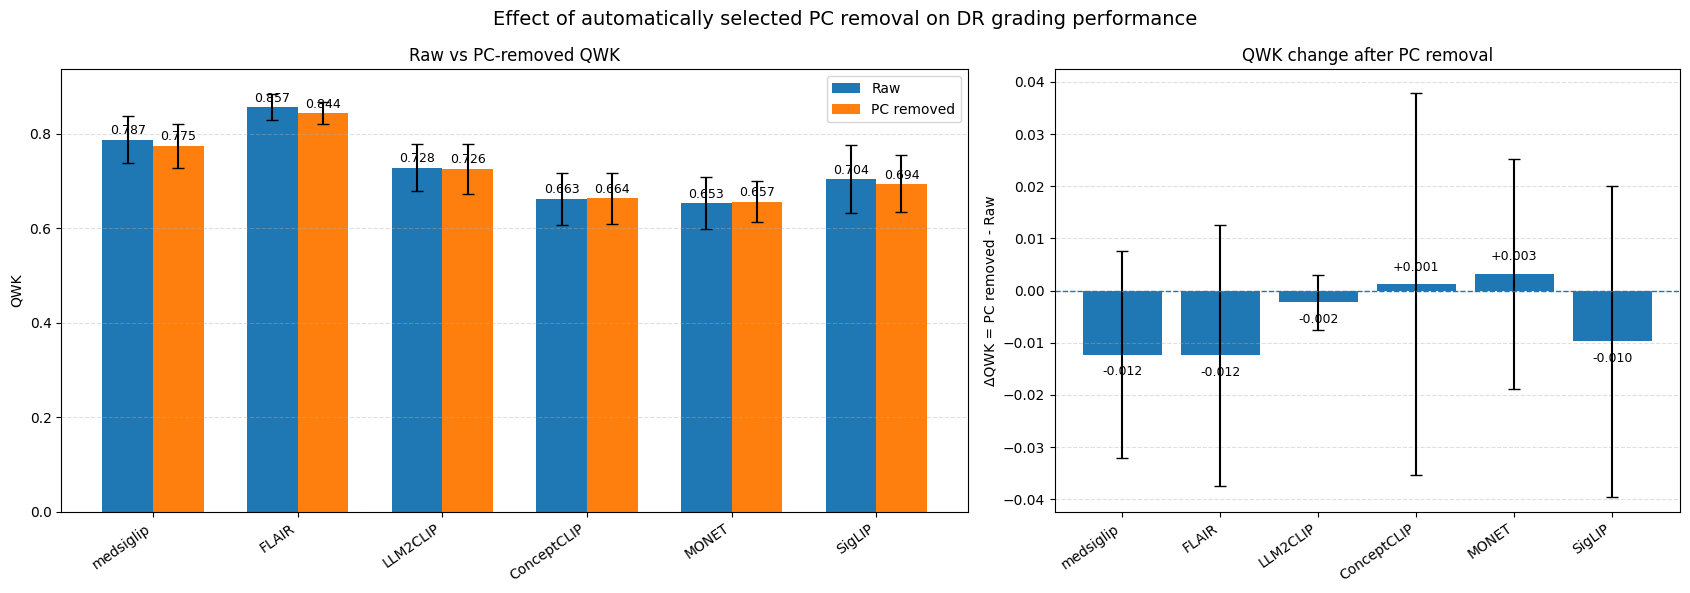

图片已保存到: 0518\output\qwk\figures\qwk_6_models_raw_clean_delta.png


In [45]:
# ==========================================
# 6个模型 QWK 结果效果图
# 使用 all_summary_df
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------
# 1. 使用你刚才循环得到的总汇总表
# -------------------------------------------------
plot_df = all_summary_df.copy()

# 按你分析时的模型顺序排列
plot_df["model_order"] = plot_df["model_name"].apply(
    lambda x: model_list.index(x) if x in model_list else 999
)
plot_df = plot_df.sort_values("model_order").reset_index(drop=True)

# 简化模型名，方便图上显示
plot_df["model_label"] = (
    plot_df["model_name"]
    .str.replace("FVs_", "", regex=False)
    .str.replace("LLM2CLIP-openai", "LLM2CLIP", regex=False)
)

display(plot_df[
    [
        "model_name",
        "raw_qwk_mean",
        "clean_qwk_mean",
        "delta_qwk_mean",
        "n_removed_mean",
        "removed_pcs_by_fold",
    ]
])

# -------------------------------------------------
# 2. 取出需要画图的数据
# -------------------------------------------------
models = plot_df["model_label"].tolist()
x = np.arange(len(models))
bar_w = 0.35

raw_mean = plot_df["raw_qwk_mean"].to_numpy()
clean_mean = plot_df["clean_qwk_mean"].to_numpy()
delta_mean = plot_df["delta_qwk_mean"].to_numpy()

raw_std = plot_df["raw_qwk_std"].to_numpy()
clean_std = plot_df["clean_qwk_std"].to_numpy()
delta_std = plot_df["delta_qwk_std"].to_numpy()

# -------------------------------------------------
# 3. 画图：左边 Raw vs PC-removed，右边 ΔQWK
# -------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 6),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

ax1, ax2 = axes

# ===== 左图：去除前后 QWK 对比 =====
ax1.bar(
    x - bar_w / 2,
    raw_mean,
    width=bar_w,
    yerr=raw_std,
    capsize=4,
    label="Raw"
)

ax1.bar(
    x + bar_w / 2,
    clean_mean,
    width=bar_w,
    yerr=clean_std,
    capsize=4,
    label="PC removed"
)

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=35, ha="right")
ax1.set_ylabel("QWK")
ax1.set_title("Raw vs PC-removed QWK")
ax1.set_ylim(0, max(raw_mean.max(), clean_mean.max()) + 0.08)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend()

# 数值标注
for i, v in enumerate(raw_mean):
    ax1.text(
        i - bar_w / 2,
        v + 0.005,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for i, v in enumerate(clean_mean):
    ax1.text(
        i + bar_w / 2,
        v + 0.005,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ===== 右图：QWK变化量 =====
ax2.bar(
    x,
    delta_mean,
    yerr=delta_std,
    capsize=4
)

ax2.axhline(0, linestyle="--", linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=35, ha="right")
ax2.set_ylabel("ΔQWK = PC removed - Raw")
ax2.set_title("QWK change after PC removal")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

# delta 纵轴范围自动留白
delta_abs_max = max(abs(delta_mean.min()), abs(delta_mean.max()))
ax2.set_ylim(-delta_abs_max - 0.03, delta_abs_max + 0.03)

# 数值标注
for i, v in enumerate(delta_mean):
    if v >= 0:
        ax2.text(
            i,
            v + 0.002,
            f"{v:+.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )
    else:
        ax2.text(
            i,
            v - 0.002,
            f"{v:+.3f}",
            ha="center",
            va="top",
            fontsize=9
        )

plt.suptitle(
    "Effect of automatically selected PC removal on DR grading performance",
    fontsize=14
)

plt.tight_layout()

# -------------------------------------------------
# 4. 保存图片
# -------------------------------------------------
out_dir = Path("0518/output/qwk/figures")
out_dir.mkdir(parents=True, exist_ok=True)

save_path = out_dir / "qwk_6_models_raw_clean_delta.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"图片已保存到: {save_path}")